# Phase 2 — Grouped + stratified 70/15/15 split

The dataset's *official* split has confirmed group leakage (source-video segments spread across train/val/test). This rebuilds the split from scratch: grouped on `source_group_id` (no source video crosses a split), stratified on `emotion_id` (class proportions track the global distribution).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]  # notebooks/ -> project/ -> repo root
sys.path.insert(0, str(REPO_ROOT))

from project.config import load_config, resolve_path

cfg = load_config()


In [2]:
import pandas as pd
from project.preprocessing.split import build_splits

manifest = pd.read_csv(resolve_path(cfg, 'paths.manifest_csv'))
manifest = build_splits(cfg, manifest)

PHASE 2 — Grouped + stratified 70/15/15 split
  [WARN] 12 group(s) contain rows with different emotion_id (unexpected -- using majority label per group): ['DS3__0qanF-91aJo', 'DS3__9rB_x4VSZpU', 'DS3__Bx51eegLTY8', 'DS3__RvzUq6O8zS0', 'DS3__V-WGkADkVnM', 'DS3__ZkW-K5RQdzo', 'DS3__fPO76Jlnz6c', 'DS3__mllXxyHTzfg', 'DS3__mwhwGmoYv1s', 'DS3__n4PE6gK2odM', 'DS3__pj6k-EFxqAI', 'DS3__umeajkNL5Hw']
  [OK] no source_group_id crosses a split boundary

Split sizes (rows):
split
train    2232
val       479
test      478
Name: count, dtype: int64

Per-split emotion distribution (%):
emotion_label  exciting  fear  relax   sad  tense
split                                            
train              21.6  16.8   28.6  18.6   14.5
val                21.7  16.9   28.4  18.8   14.2
test               21.8  16.9   28.5  18.6   14.2

Per-split dataset_source distribution (rows):
dataset_source   DS1  DS2  DS3
split                         
train           1870  190  172
val              395   59   25
t

In [3]:
manifest.to_csv(resolve_path(cfg, 'paths.manifest_csv'), index=False)
for split_name, path_key in [('train','paths.train_csv'), ('val','paths.val_csv'), ('test','paths.test_csv')]:
    out_path = resolve_path(cfg, path_key)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    manifest[manifest['split'] == split_name].drop(columns=['split']).to_csv(out_path, index=False)
    print('saved', split_name, '->', out_path)

saved train -> /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/data/train.csv
saved val -> /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/data/val.csv
saved test -> /Users/rafiabhista/Documents/code/apple/c1_audio/emomv_2/project/data/test.csv


### Per-split emotion distribution

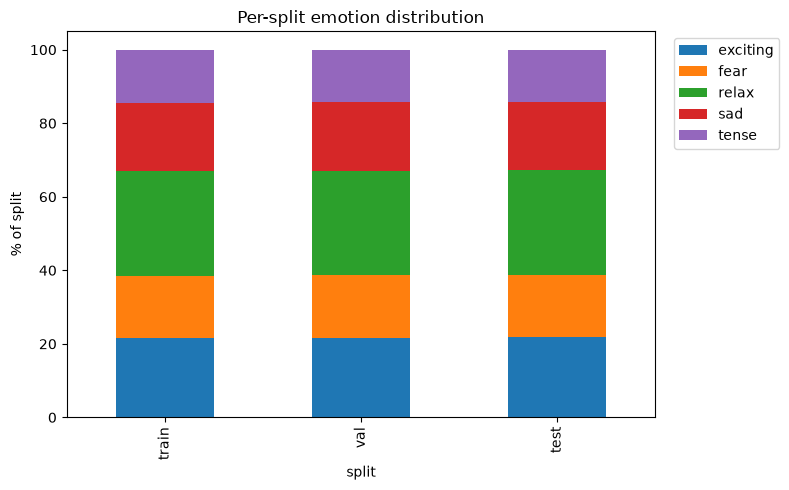

In [4]:
import matplotlib.pyplot as plt

dist = manifest.groupby(['split','emotion_label']).size().unstack(fill_value=0)
dist = dist.reindex(['train','val','test'])
(100 * dist.div(dist.sum(axis=1), axis=0)).plot(kind='bar', stacked=True, figsize=(8,5))
plt.ylabel('% of split'); plt.title('Per-split emotion distribution'); plt.legend(bbox_to_anchor=(1.02,1))
plt.tight_layout(); plt.show()